In [65]:
import pandas as pd
import numpy as np
df=pd.read_csv('poly.csv')
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [66]:
df.dtypes

sno              int64
Temperature      int64
Pressure       float64
dtype: object

In [67]:
df.drop(columns='sno',inplace=True)
df

,Temperature,Pressure
0,0,0.0002
1,20,0.0012
2,40,0.0060
3,60,0.0300
4,80,0.0900
5,100,0.2700


In [68]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
print(x)
print(y)

   Temperature
0            0
1           20
2           40
3           60
4           80
5          100
0    0.0002
1    0.0012
2    0.0060
3    0.0300
4    0.0900
5    0.2700
Name: Pressure, dtype: float64


In [69]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x,y)
y_pred=model.predict(x)
y_pred

array([-0.05086667, -0.00402667,  0.04281333,  0.08965333,  0.13649333,
        0.18333333])

In [70]:
y

0    0.0002
1    0.0012
2    0.0060
3    0.0300
4    0.0900
5    0.2700
Name: Pressure, dtype: float64

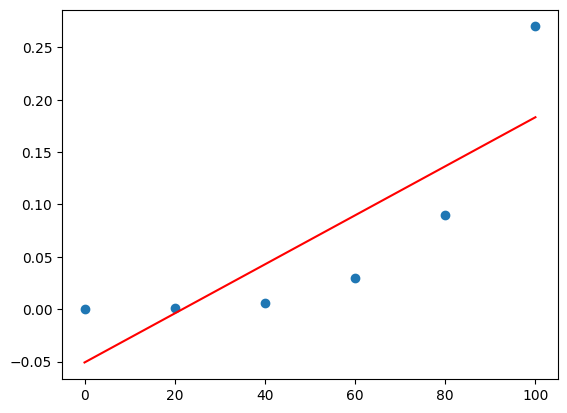

In [71]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.plot(x,y_pred,color='r')

In [72]:
from sklearn.metrics import mean_absolute_percentage_error,r2_score
mape=mean_absolute_percentage_error(y,y_pred)
mape

44.775078189300416

In [73]:
score=r2_score(y,y_pred)
score

0.690349972603981

#POLYNOMIAL

In [74]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
x_poly=poly.fit_transform(x)
x_poly

array([[1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [1.00e+00, 2.00e+01, 4.00e+02, 8.00e+03],
       [1.00e+00, 4.00e+01, 1.60e+03, 6.40e+04],
       [1.00e+00, 6.00e+01, 3.60e+03, 2.16e+05],
       [1.00e+00, 8.00e+01, 6.40e+03, 5.12e+05],
       [1.00e+00, 1.00e+02, 1.00e+04, 1.00e+06]])

In [75]:
x_poly.shape

(6, 4)

In [76]:
model1=LinearRegression()
model1.fit(x_poly,y)
y_poly=model1.predict(x_poly)
y_poly

array([-0.00198889,  0.00724444,  0.00371111,  0.02248889,  0.09865556,
        0.26728889])

In [77]:
mape1=mean_absolute_percentage_error(y,y_poly)
score1=r2_score(y,y_poly)
mape1

2.7865912208924066

In [78]:
score1

0.9966691251761722

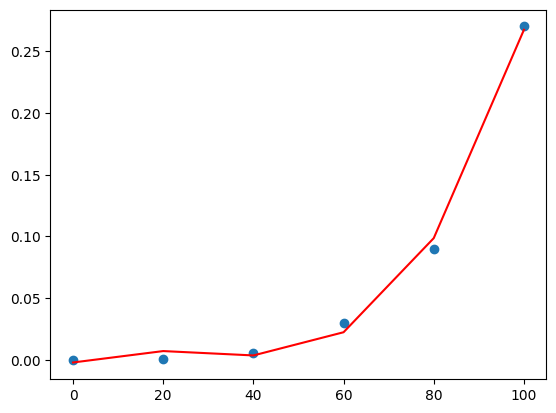

In [79]:
plt.scatter(x,y)
plt.plot(x,y_poly,color='r')

In [82]:
df1=pd.DataFrame({'Actual_value':y,'Simple Linear Regression':y_pred,'Polynomial Regression':y_poly})
df1

,Actual_value,Simple Linear Regression,Polynomial Regression
0,0.0002,-0.050867,-0.001989
1,0.0012,-0.004027,0.007244
2,0.0060,0.042813,0.003711
3,0.0300,0.089653,0.022489
4,0.0900,0.136493,0.098656
5,0.2700,0.183333,0.267289
